In [76]:
import pandas as pd

df = pd.read_csv("../data/StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23.0,84.0,Low,High,No,7,73,Low,Yes,0.0,Low,Medium,Public,Positive,3.0,No,High School,Near,Male,67.0
1,19.0,64.0,Low,Medium,No,8,59,Low,Yes,NaN,Medium,Medium,Public,Negative,4.0,No,College,Moderate,Female,61.0
2,24.0,98.0,Medium,Medium,Yes,7,91,Medium,Yes,2.0,Medium,Medium,Public,Neutral,4.0,No,Postgraduate,Near,Male,74.0
3,29.0,89.0,Low,Medium,Yes,8,98,Medium,Yes,1.0,Medium,Medium,Public,Negative,4.0,No,High School,Moderate,Male,71.0
4,19.0,92.0,Medium,Medium,Yes,6,65,Medium,Yes,3.0,Medium,High,Public,Neutral,4.0,No,College,Near,Female,70.0


In [77]:
df.shape

(6607, 20)

In [78]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='str')

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6605 non-null   float64
 1   Attendance                  6605 non-null   float64
 2   Parental_Involvement        6606 non-null   str    
 3   Access_to_Resources         6605 non-null   str    
 4   Extracurricular_Activities  6605 non-null   str    
 5   Sleep_Hours                 6607 non-null   int64  
 6   Previous_Scores             6607 non-null   int64  
 7   Motivation_Level            6606 non-null   str    
 8   Internet_Access             6606 non-null   str    
 9   Tutoring_Sessions           6606 non-null   float64
 10  Family_Income               6606 non-null   str    
 11  Teacher_Quality             6528 non-null   str    
 12  School_Type                 6605 non-null   str    
 13  Peer_Influence              6606 non-null   

In [80]:
df.isnull().sum()

Hours_Studied                  2
Attendance                     2
Parental_Involvement           1
Access_to_Resources            2
Extracurricular_Activities     2
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               1
Internet_Access                1
Tutoring_Sessions              1
Family_Income                  1
Teacher_Quality               79
School_Type                    2
Peer_Influence                 1
Physical_Activity              3
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            68
Gender                         1
Exam_Score                     2
dtype: int64

In [81]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

Parental_Education_Level      90
Teacher_Quality               79
Distance_from_Home            68
Physical_Activity              3
Hours_Studied                  2
Attendance                     2
Access_to_Resources            2
Extracurricular_Activities     2
Exam_Score                     2
School_Type                    2
Family_Income                  1
Internet_Access                1
Motivation_Level               1
Parental_Involvement           1
Tutoring_Sessions              1
Peer_Influence                 1
Gender                         1
dtype: int64

In [82]:
df.duplicated().sum()

np.int64(0)

In [83]:
df[df["Exam_Score"].isnull()]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
97,22.0,81.0,Medium,Medium,Yes,7,77,Low,Yes,2.0,Medium,Medium,Public,Positive,3.0,No,Postgraduate,Far,Female,NaN
1593,25.0,96.0,Medium,Low,Yes,9,55,High,Yes,2.0,Medium,High,Public,Neutral,4.0,No,High School,Moderate,Male,NaN


In [84]:
df = df.dropna(subset=["Exam_Score"])

In [85]:
df["Exam_Score"].isnull().sum()

np.int64(0)

In [86]:
df_clean = df.copy()

In [87]:
numeric_columns = [
    "Hours_Studied",
    "Attendance",
    "Tutoring_Sessions",
    "Physical_Activity"
]

for column in numeric_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

In [88]:
categorical_columns = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Extracurricular_Activities",
    "Motivation_Level",
    "Internet_Access",
    "Family_Income",
    "Teacher_Quality",
    "School_Type",
    "Peer_Influence",
    "Parental_Education_Level",
    "Distance_from_Home",
    "Gender"
]

for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].mode()[0])

In [89]:
df_clean.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [90]:
df_clean.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000
mean,19.972748,79.946404,7.028766,75.073278,1.493414,2.967146,67.215291
std,5.994838,11.734837,1.468142,14.399827,1.230724,1.030859,4.217186
min,0.000000,-91.000000,4.000000,50.000000,0.000000,0.000000,-65.000000
25%,16.000000,70.000000,6.000000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.000000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.000000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.000000,100.000000,8.000000,6.000000,101.000000


In [91]:
df_clean.shape

(6605, 20)

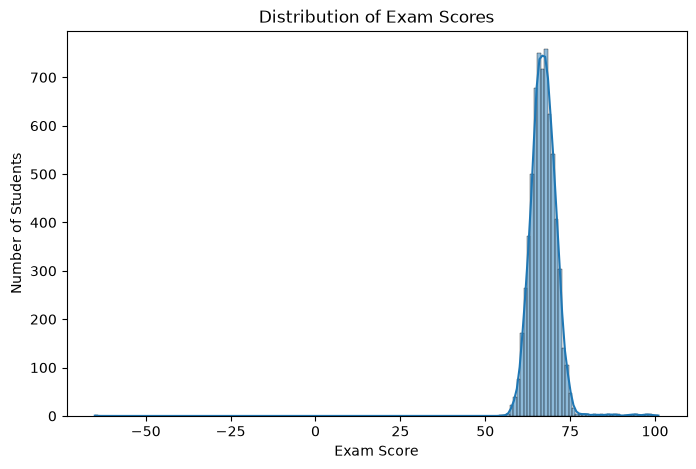

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(df_clean["Exam_Score"], kde=True)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.savefig("../images/score_distribution.png")

plt.show()

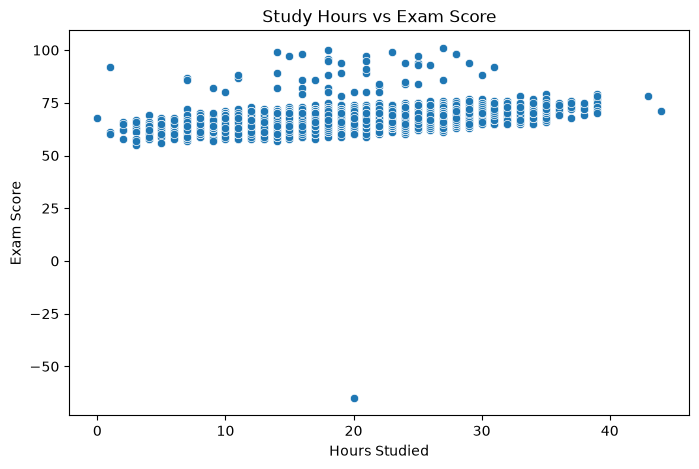

In [93]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Hours_Studied",
    y="Exam_Score"
)

plt.title("Study Hours vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.savefig("../images/hours_studied_vs_score.png", bbox_inches="tight")
plt.show()

In [94]:
df_clean["Hours_Studied"].corr(df_clean["Exam_Score"])

np.float64(0.4104071317970006)

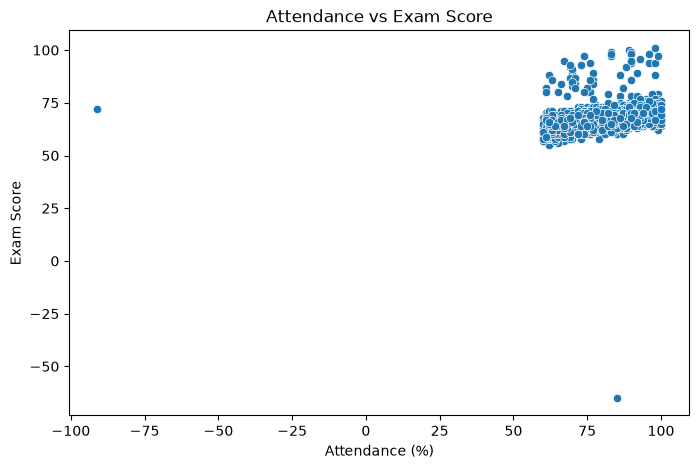

In [95]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Attendance",
    y="Exam_Score"
)

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")
plt.savefig("../images/attendance_vs_score.png", bbox_inches="tight")
plt.show()

In [96]:
df_clean["Attendance"].corr(df_clean["Exam_Score"])

np.float64(0.5227248023237224)

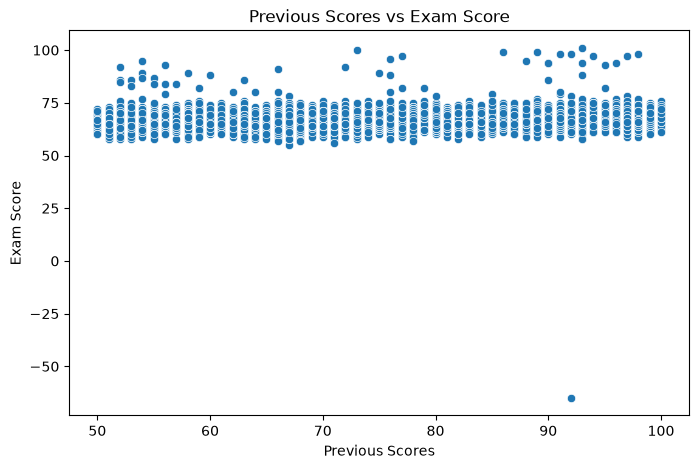

In [97]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Previous_Scores",
    y="Exam_Score"
)

plt.title("Previous Scores vs Exam Score")
plt.xlabel("Previous Scores")
plt.ylabel("Exam Score")
plt.savefig("../images/previous_scores_vs_exam_score.png", bbox_inches="tight")
plt.show()

In [98]:
df_clean["Previous_Scores"].corr(df_clean["Exam_Score"])

np.float64(0.15626095038533402)

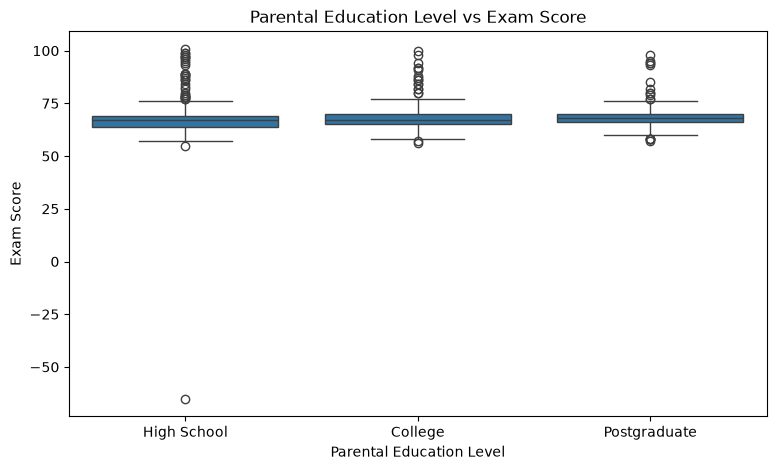

In [99]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="Parental_Education_Level",
    y="Exam_Score"
)

plt.title("Parental Education Level vs Exam Score")
plt.xlabel("Parental Education Level")
plt.ylabel("Exam Score")
plt.savefig("../images/parental_education_vs_score.png", bbox_inches="tight")
plt.show()

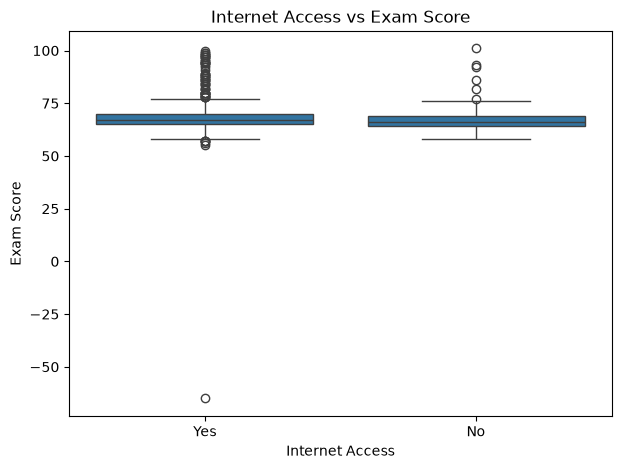

In [100]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_clean,
    x="Internet_Access",
    y="Exam_Score"
)

plt.title("Internet Access vs Exam Score")
plt.xlabel("Internet Access")
plt.ylabel("Exam Score")
plt.savefig("../images/internet_access_vs_score.png", bbox_inches="tight")
plt.show()

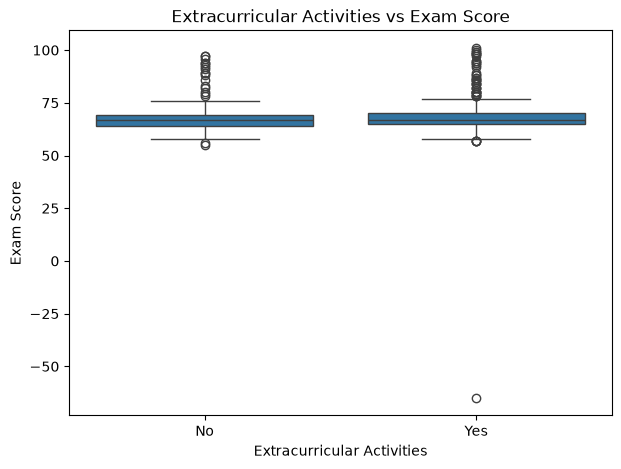

In [101]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_clean,
    x="Extracurricular_Activities",
    y="Exam_Score"
)

plt.title("Extracurricular Activities vs Exam Score")
plt.xlabel("Extracurricular Activities")
plt.ylabel("Exam Score")
plt.savefig("../images/extracurricular_vs_score.png", bbox_inches="tight")
plt.show()

In [102]:
df_clean.select_dtypes(include="number").columns

Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score'],
      dtype='str')

In [103]:
correlation_matrix = df_clean.select_dtypes(include="number").corr()

correlation_matrix

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Hours_Studied,1.000000,-0.011857,0.011186,0.025239,-0.014822,0.004070,0.410407
Attendance,-0.011857,1.000000,-0.015898,-0.020600,0.015147,-0.026507,0.522725
Sleep_Hours,0.011186,-0.015898,1.000000,-0.021473,-0.012382,-0.001076,-0.018976
Previous_Scores,0.025239,-0.020600,-0.021473,1.000000,-0.012909,-0.010304,0.156261
Tutoring_Sessions,-0.014822,0.015147,-0.012382,-0.012909,1.000000,0.017315,0.142618
Physical_Activity,0.004070,-0.026507,-0.001076,-0.010304,0.017315,1.000000,0.020785
Exam_Score,0.410407,0.522725,-0.018976,0.156261,0.142618,0.020785,1.000000


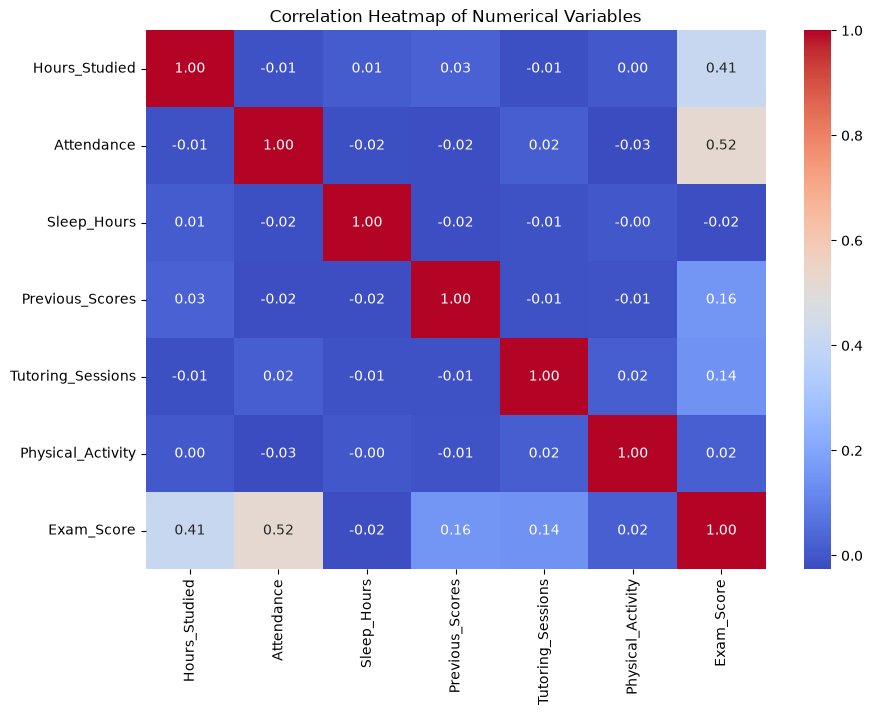

In [104]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

In [105]:
df_clean[df_clean["Exam_Score"] < 0]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
2098,20.0,85.0,Medium,Medium,Yes,8,92,Low,Yes,2.0,Medium,Medium,Public,Negative,4.0,No,High School,Far,Female,-65.0


In [106]:
df_clean.loc[2098, "Exam_Score"]

np.float64(-65.0)

In [107]:
df_clean.loc[2098]

Hours_Studied                        20.0
Attendance                           85.0
Parental_Involvement               Medium
Access_to_Resources                Medium
Extracurricular_Activities            Yes
Sleep_Hours                             8
Previous_Scores                        92
Motivation_Level                      Low
Internet_Access                       Yes
Tutoring_Sessions                     2.0
Family_Income                      Medium
Teacher_Quality                    Medium
School_Type                        Public
Peer_Influence                   Negative
Physical_Activity                     4.0
Learning_Disabilities                  No
Parental_Education_Level      High School
Distance_from_Home                    Far
Gender                             Female
Exam_Score                          -65.0
Name: 2098, dtype: object

In [108]:
df_clean = df_clean[df_clean["Exam_Score"] >= 0].copy()

In [109]:
df_clean["Exam_Score"].min()

np.float64(55.0)

In [110]:
correlation_matrix = df_clean.select_dtypes(include="number").corr()

correlation_matrix

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Hours_Studied,1.000000,-0.011858,0.011186,0.025240,-0.014822,0.004069,0.444874
Attendance,-0.011858,1.000000,-0.015942,-0.020679,0.015120,-0.026575,0.568819
Sleep_Hours,0.011186,-0.015942,1.000000,-0.021594,-0.012424,-0.001177,-0.017165
Previous_Scores,0.025240,-0.020679,-0.021594,1.000000,-0.012984,-0.010484,0.175443
Tutoring_Sessions,-0.014822,0.015120,-0.012424,-0.012984,1.000000,0.017254,0.156707
Physical_Activity,0.004069,-0.026575,-0.001177,-0.010484,0.017254,1.000000,0.027688
Exam_Score,0.444874,0.568819,-0.017165,0.175443,0.156707,0.027688,1.000000


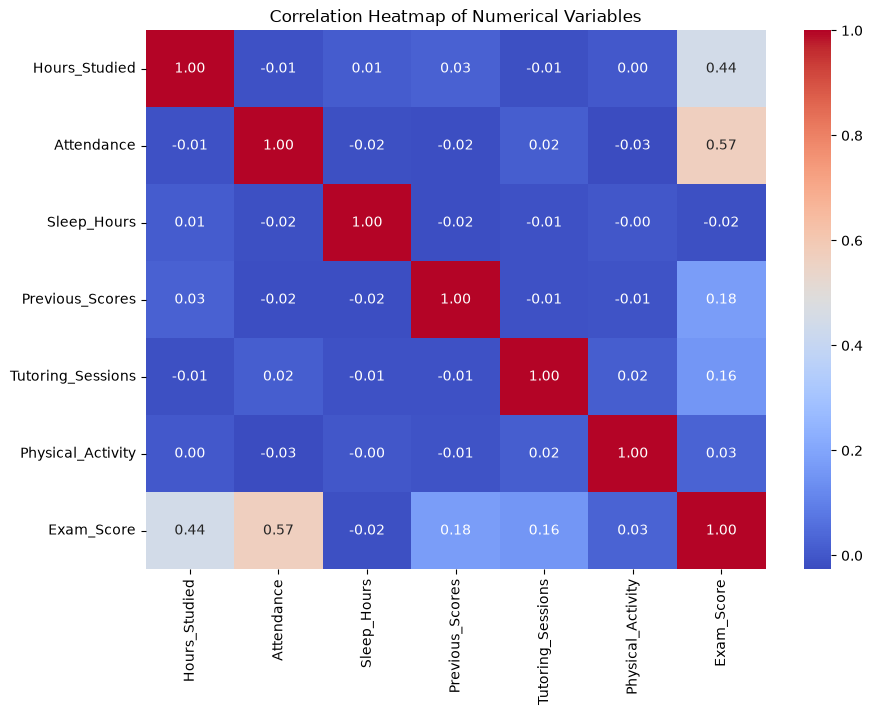

In [111]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.savefig("../images/correlation_heatmap.png", bbox_inches="tight")
plt.show()

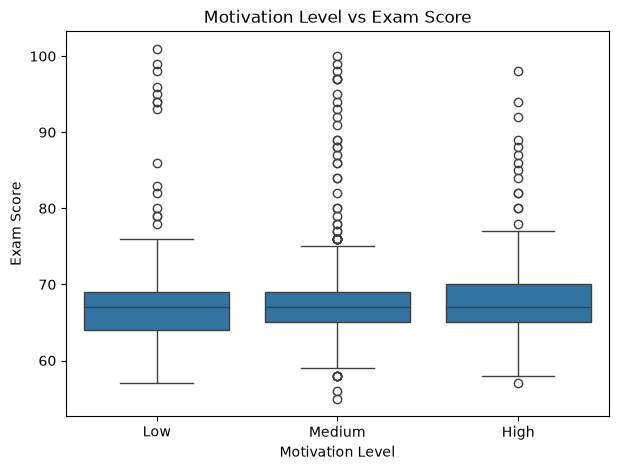

In [112]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_clean,
    x="Motivation_Level",
    y="Exam_Score"
)

plt.title("Motivation Level vs Exam Score")
plt.xlabel("Motivation Level")
plt.ylabel("Exam Score")

plt.show()

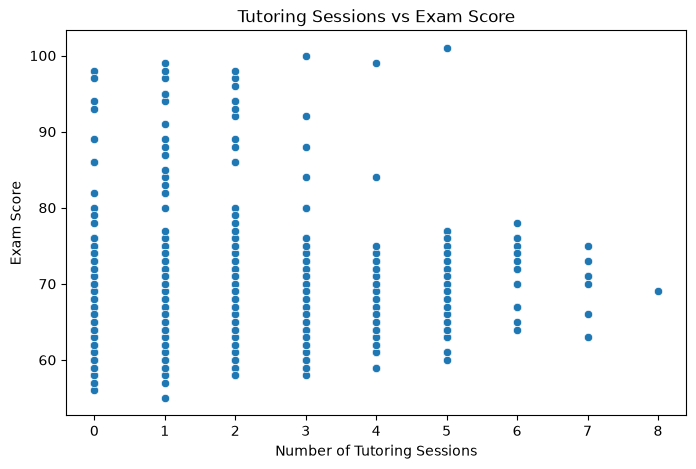

In [113]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Tutoring_Sessions",
    y="Exam_Score"
)

plt.title("Tutoring Sessions vs Exam Score")
plt.xlabel("Number of Tutoring Sessions")
plt.ylabel("Exam Score")

plt.show()

In [114]:
df_clean["Tutoring_Sessions"].corr(df_clean["Exam_Score"])

np.float64(0.15670722733047804)

In [115]:
X = df_clean.drop("Exam_Score", axis=1)
y = df_clean["Exam_Score"]

In [116]:
X.shape

(6604, 19)

In [117]:
y.shape

(6604,)

In [118]:
numeric_features = X.select_dtypes(include="number").columns.tolist()

categorical_features = X.select_dtypes(exclude="number").columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Categorical features:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [119]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [120]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5283, 19)
Testing features: (1321, 19)
Training target: (5283,)
Testing target: (1321,)


In [121]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [122]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [123]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Parental_Education_Level','Distance_from_Home','Gender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automati

In [124]:
y_pred_linear = linear_model.predict(X_test)

In [125]:
y_pred_linear[:10]

array([64.86487592, 65.67723432, 64.41802199, 70.25801142, 69.34333854,
       67.36440096, 65.26454206, 73.11030787, 63.32422405, 68.29719809])

In [126]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression Results
MAE : 0.4779095436208677
RMSE: 1.8559949289173978
R²  : 0.7577453878515157


In [127]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [128]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Parental_Education_Level','Distance_from_Home','Gender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automati

In [129]:
y_pred_rf = random_forest_model.predict(X_test)

In [130]:
y_pred_rf[:10]

array([66.525, 66.34 , 65.315, 68.62 , 69.295, 68.855, 65.035, 73.13 ,
       63.13 , 70.805])

In [131]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
MAE : 1.0994700984102952
RMSE: 2.1408720728711694
R²  : 0.6776706017422003


In [132]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

In [133]:
gradient_boosting_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Parental_Education_Level','Distance_from_Home','Gender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automati

In [134]:
y_pred_gb = gradient_boosting_model.predict(X_test)

In [135]:
y_pred_gb[:10]

array([65.93490922, 65.16770243, 64.83251171, 69.62271665, 68.9313269 ,
       68.32051665, 65.39529193, 73.38264788, 63.52368516, 69.16868935])

In [136]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("MAE :", mae_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)

Gradient Boosting Results
MAE : 0.8152215568768572
RMSE: 1.9782665903727539
R²  : 0.724774850288948


In [137]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae_linear,
        mae_rf,
        mae_gb
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf,
        rmse_gb
    ],
    "R²": [
        r2_linear,
        r2_rf,
        r2_gb
    ]
})

model_comparison

,Model,MAE,RMSE,R²
0,Linear Regression,0.477910,1.855995,0.757745
1,Random Forest,1.099470,2.140872,0.677671
2,Gradient Boosting,0.815222,1.978267,0.724775


In [138]:
feature_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()

print("Number of processed features:", len(feature_names))
print(feature_names)

Number of processed features: 40
['num__Hours_Studied' 'num__Attendance' 'num__Sleep_Hours'
 'num__Previous_Scores' 'num__Tutoring_Sessions' 'num__Physical_Activity'
 'cat__Parental_Involvement_High' 'cat__Parental_Involvement_Low'
 'cat__Parental_Involvement_Medium' 'cat__Access_to_Resources_High'
 'cat__Access_to_Resources_Low' 'cat__Access_to_Resources_Medium'
 'cat__Extracurricular_Activities_No'
 'cat__Extracurricular_Activities_Yes' 'cat__Motivation_Level_High'
 'cat__Motivation_Level_Low' 'cat__Motivation_Level_Medium'
 'cat__Internet_Access_No' 'cat__Internet_Access_Yes'
 'cat__Family_Income_High' 'cat__Family_Income_Low'
 'cat__Family_Income_Medium' 'cat__Teacher_Quality_High'
 'cat__Teacher_Quality_Low' 'cat__Teacher_Quality_Medium'
 'cat__School_Type_Private' 'cat__School_Type_Public'
 'cat__Peer_Influence_Negative' 'cat__Peer_Influence_Neutral'
 'cat__Peer_Influence_Positive' 'cat__Learning_Disabilities_No'
 'cat__Learning_Disabilities_Yes' 'cat__Parental_Education_Level_Co

In [139]:
feature_importance = random_forest_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
1,num__Attendance,0.378482
0,num__Hours_Studied,0.243005
3,num__Previous_Scores,0.081362
4,num__Tutoring_Sessions,0.031959
5,num__Physical_Activity,0.023701
2,num__Sleep_Hours,0.022959
9,cat__Access_to_Resources_High,0.017238
6,cat__Parental_Involvement_High,0.016397
7,cat__Parental_Involvement_Low,0.014907
10,cat__Access_to_Resources_Low,0.012555


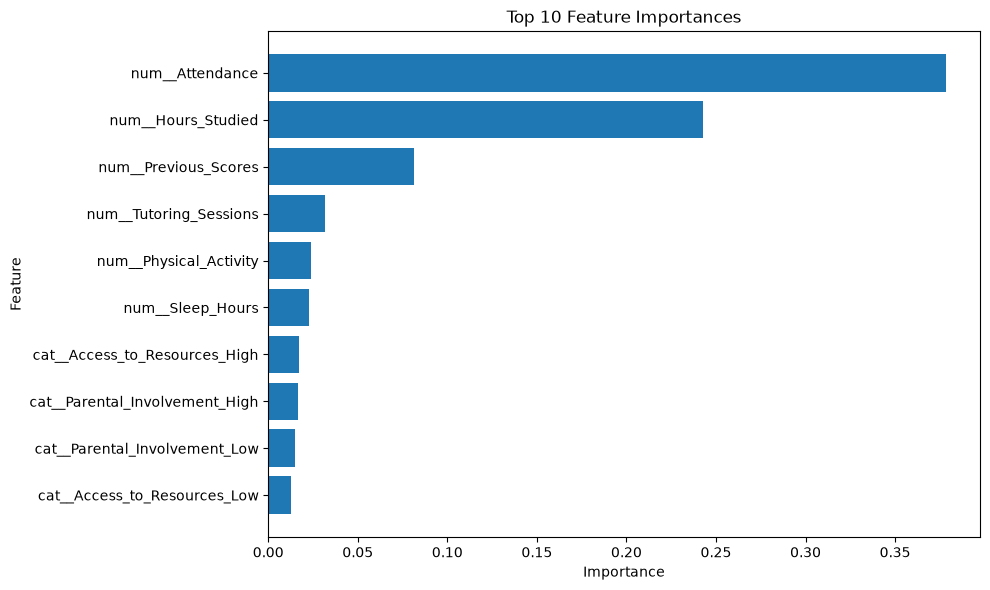

In [140]:
top_features = importance_df.head(10).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Final Findings

### Exploratory Data Analysis

- Attendance showed the strongest positive correlation with Exam Score among the numerical features, with a correlation of approximately 0.57.
- Hours Studied also showed a moderate positive correlation with Exam Score, with a correlation of approximately 0.44.
- Previous Scores and Tutoring Sessions showed weaker positive relationships with Exam Score.
- Sleep Hours and Physical Activity showed very weak relationships with Exam Score.
- The categorical variables such as Internet Access, Extracurricular Activities, Parental Education Level, and Motivation Level showed substantial overlap in exam-score distributions across their groups.
- An invalid Exam Score value of -65 was identified during data validation and removed before the final analysis.

### Machine Learning Results

Three regression models were trained and evaluated:

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Linear Regression | 0.478 | 1.856 | 0.758 |
| Random Forest | 1.100 | 2.141 | 0.678 |
| Gradient Boosting | 0.815 | 1.978 | 0.725 |

Among the three models tested on the test set, Linear Regression produced the lowest MAE and RMSE and the highest R².

### Feature Importance

Random Forest feature importance showed that Attendance and Hours Studied were the two most important individual features in the model. Previous Scores was the next most important numerical feature.

### Conclusion

This analysis examined the factors associated with student exam performance and developed machine learning models to predict Exam Score. The exploratory analysis and model feature importance both highlighted Attendance and Hours Studied as important factors in the prediction task. The comparison of three regression models showed that Linear Regression achieved the strongest performance on the test set for this dataset and preprocessing approach.